In [3]:
# =========================================================
# DỰ ĐOÁN DOANH THU PHIM BẰNG LINEAR REGRESSION
# =========================================================

# =========================================================
# 1. IMPORT THƯ VIỆN
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [4]:
# =========================================================
# 2. ĐỌC DATASET
# =========================================================

df = pd.read_csv(
    'boxoffice.csv',
    encoding='latin-1'
)

print("\n===== DATASET HEAD =====")

print(df.head())

# =========================================================
# 3. XÓA CÁC CỘT KHÔNG CẦN THIẾT
# =========================================================

to_remove = [
    'world_revenue',
    'opening_revenue',
    'budget',
    'release_days'
]

df.drop(
    to_remove,
    axis=1,
    inplace=True
)

# =========================================================
# 4. XỬ LÝ GIÁ TRỊ THIẾU
# =========================================================

for col in ['MPAA', 'genres']:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

df.dropna(inplace=True)

df.reset_index(
    drop=True,
    inplace=True
)

# =========================================================
# 5. CHUYỂN DỮ LIỆU SANG DẠNG SỐ
# =========================================================

# Domestic revenue
df['domestic_revenue'] = (
    df['domestic_revenue']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# Opening theaters
df['opening_theaters'] = (
    df['opening_theaters']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# Convert to numeric
df['domestic_revenue'] = pd.to_numeric(
    df['domestic_revenue'],
    errors='coerce'
)

df['opening_theaters'] = pd.to_numeric(
    df['opening_theaters'],
    errors='coerce'
)

# =========================================================
# 6. XÓA DỮ LIỆU KHÔNG HỢP LỆ
# =========================================================

df = df[df['domestic_revenue'] > 0]

df = df[df['opening_theaters'] > 0]

df.reset_index(
    drop=True,
    inplace=True
)



===== DATASET HEAD =====
           title  domestic_revenue  world_revenue   distributor  \
0   The Avengers           6026491     1274885664  Warner Bros.   
1        Titanic         169411543     1132871091        Disney   
2  Jurassic Park         107836098      583329845          Sony   
3         Avatar          51433697     1225323391        Disney   
4  The Lion King         142791649      604140729  Warner Bros.   

   opening_revenue  opening_theaters     budget   MPAA     genres  \
0        163620146               253  174687337      R  Animation   
1         85549990               122  103948486      G     Action   
2         55681429              3826  122104991  NC-17     Horror   
3        109775324              3868   46431596      G     Horror   
4         59476800              2934  203513696      R     Comedy   

   release_days  
0            16  
1           103  
2            89  
3            85  
4           158  


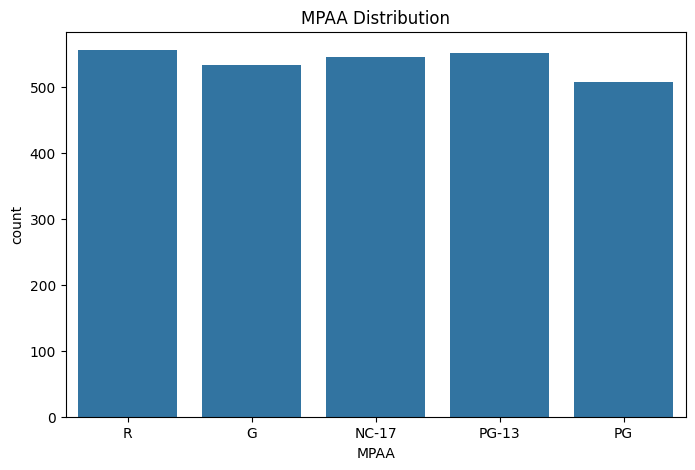

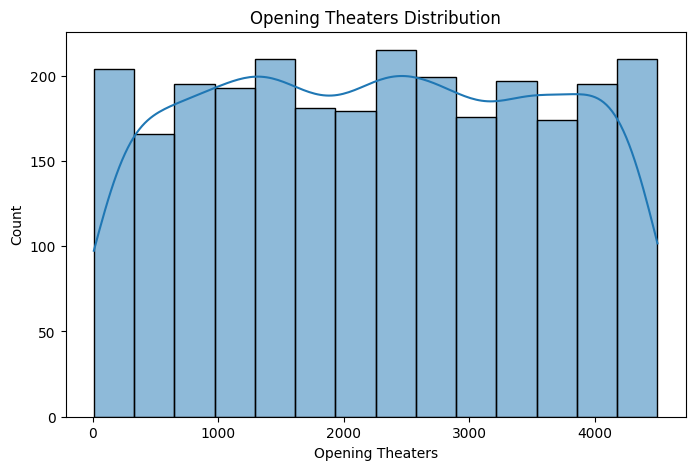

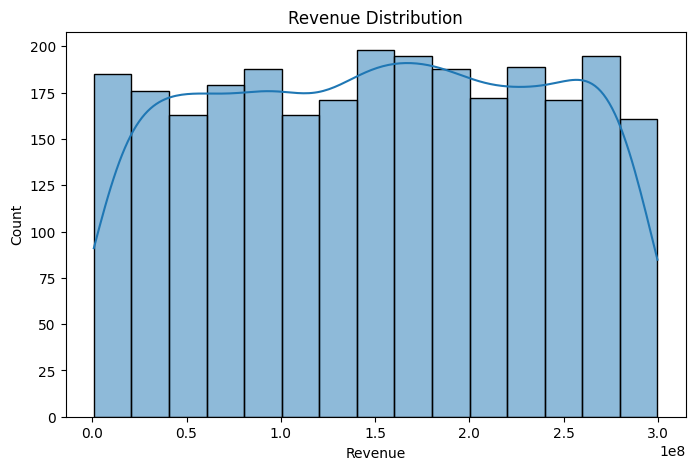

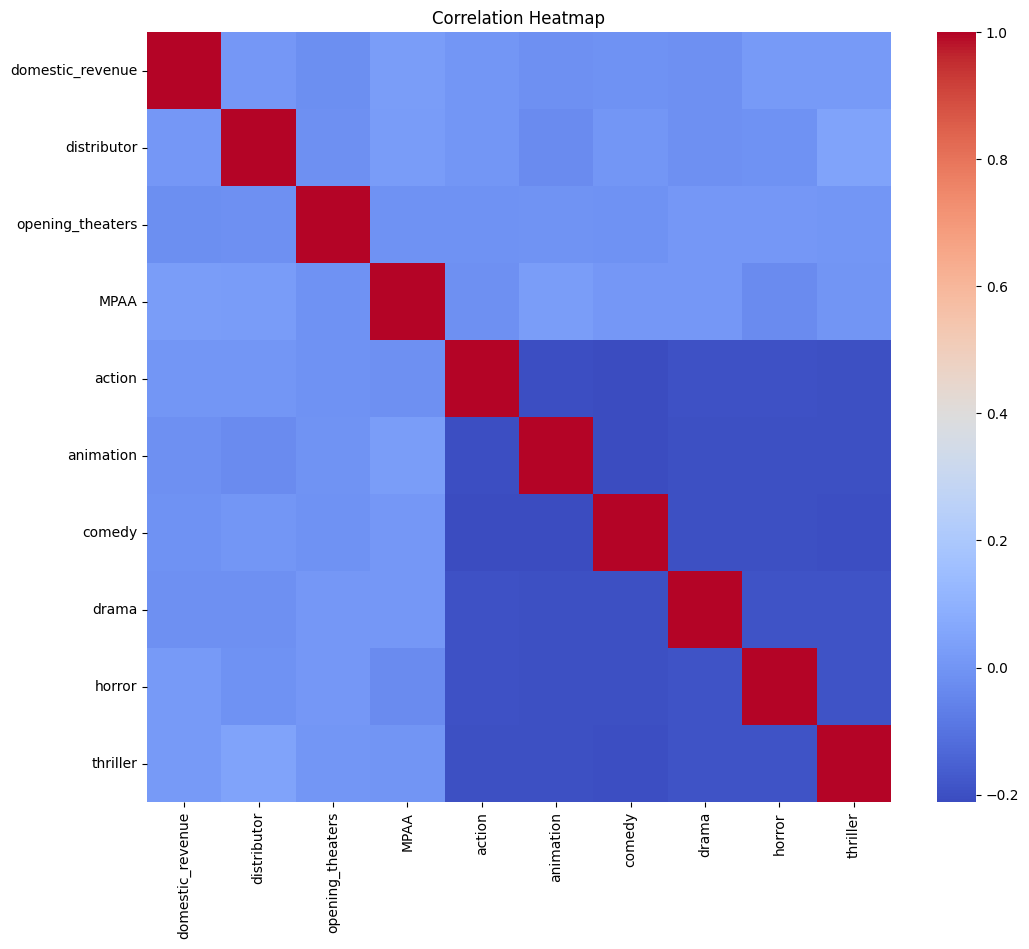


===== MODEL TRAINED =====

===== MODEL EVALUATION =====
MAE = 0.3082601159204117
RMSE = 0.4164681184086884
R2 Score = -0.01393026977414391


In [5]:
# =========================================================
# 7. LOG TRANSFORMATION
# =========================================================

features = [
    'domestic_revenue',
    'opening_theaters'
]

for col in features:

    df[col] = np.log10(
        df[col]
    )

# =========================================================
# 8. TRỰC QUAN HÓA DỮ LIỆU
# =========================================================

# =========================================================
# 8.1 BIỂU ĐỒ PHÂN BỐ MPAA
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=df['MPAA']
)

plt.title("MPAA Distribution")

plt.show()

# =========================================================
# 8.2 BIỂU ĐỒ PHÂN BỐ SỐ RẠP CHIẾU
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    10**df['opening_theaters'],
    kde=True
)

plt.title("Opening Theaters Distribution")

plt.xlabel("Opening Theaters")

plt.show()

# =========================================================
# 8.3 BIỂU ĐỒ PHÂN BỐ DOANH THU
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    10**df['domestic_revenue'],
    kde=True
)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.show()

# =========================================================
# 9. ONE HOT ENCODING CHO GENRES
# =========================================================

vectorizer = CountVectorizer()

vectorizer.fit(
    df['genres']
)

genre_features = (
    vectorizer
    .transform(df['genres'])
    .toarray()
)

genre_names = (
    vectorizer
    .get_feature_names_out()
)

for i, genre in enumerate(genre_names):

    df[genre] = genre_features[:, i]

# =========================================================
# 10. LABEL ENCODING
# =========================================================

label_encoders = {}

for col in ['distributor', 'MPAA']:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

    label_encoders[col] = le

# =========================================================
# 11. HEATMAP
# =========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# 12. TÁCH DỮ LIỆU
# =========================================================

X = df.drop(
    ['title', 'domestic_revenue', 'genres'],
    axis=1
)

y = df['domestic_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

# =========================================================
# 13. SCALE DỮ LIỆU
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# =========================================================
# 14. TRAIN MODEL
# =========================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("\n===== MODEL TRAINED =====")

# =========================================================
# 15. ĐÁNH GIÁ MODEL
# =========================================================

y_pred = model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n===== MODEL EVALUATION =====")

print("MAE =", mae)

print("RMSE =", rmse)

print("R2 Score =", r2)


ENTER NEW MOVIE INFORMATION

Available MPAA:
['G' 'NC-17' 'PG' 'PG-13' 'R']

Enter MPAA (Example: PG, PG-13, R): PG

Enter opening theaters (Example: 3000, 4000): 2000

Example genres:
Action Adventure Comedy Drama

Enter genres: Comedy

===== AVAILABLE DISTRIBUTORS =====
0 - Disney
1 - Paramount
2 - Sony
3 - Universal
4 - Warner Bros.

Choose distributor index: 3

PREDICTION RESULT

Predicted Domestic Revenue: $107,333,103.07


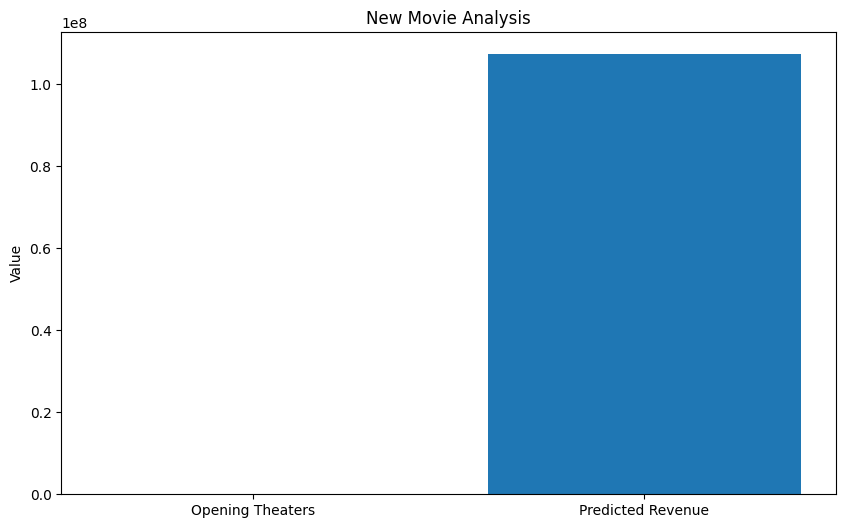

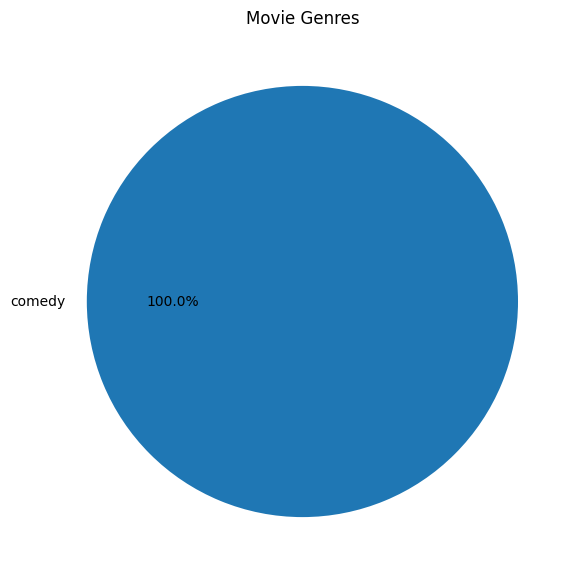

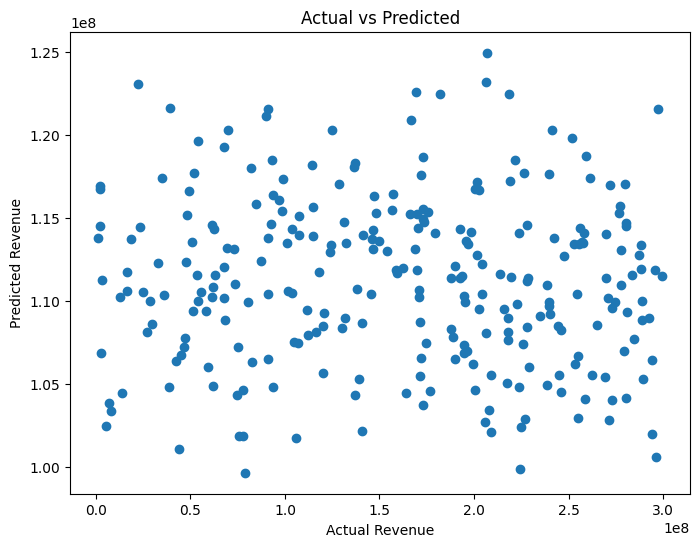

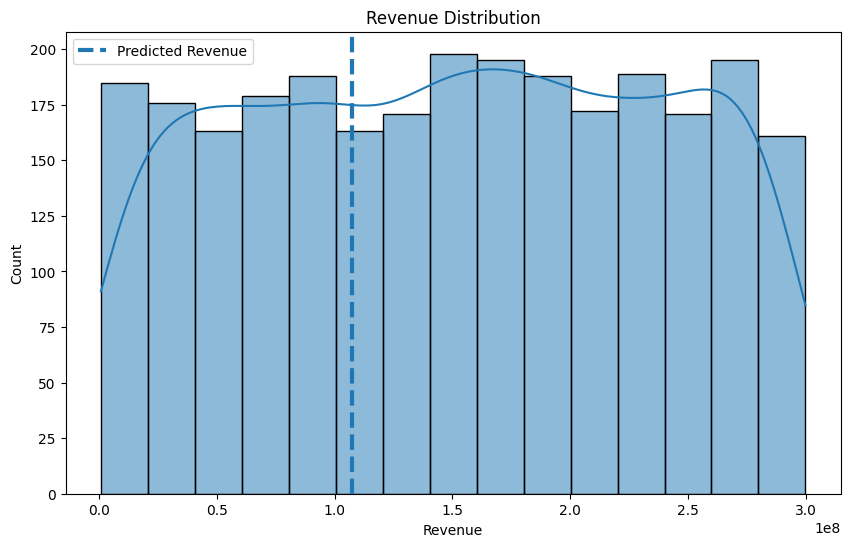

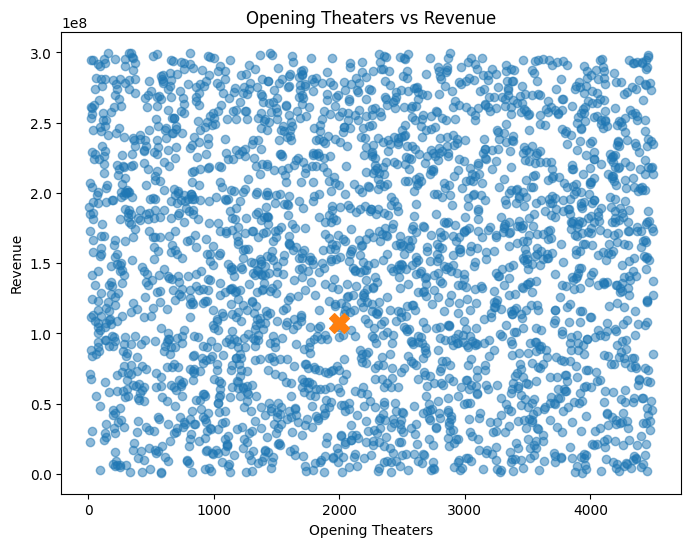

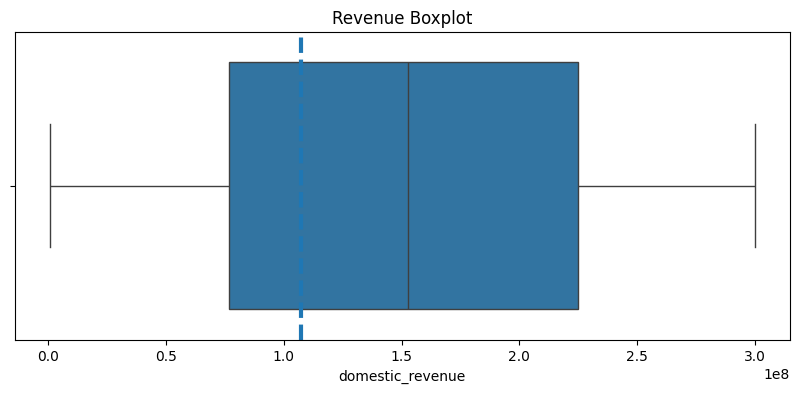

In [6]:
# =========================================================
# 16. NHẬP THÔNG TIN PHIM MỚI
# =========================================================

print("\n===================================")
print("ENTER NEW MOVIE INFORMATION")
print("===================================")

# MPAA
print("\nAvailable MPAA:")

print(
    label_encoders['MPAA'].classes_
)

mpaa = input(
    "\nEnter MPAA "
    "(Example: PG, PG-13, R): "
).strip()

# Opening theaters
opening_theaters = int(
    input(
        "\nEnter opening theaters "
        "(Example: 3000, 4000): "
    )
)

# Genres
print("\nExample genres:")

print(
    "Action Adventure Comedy Drama"
)

movie_genres = input(
    "\nEnter genres: "
)

# =========================================================
# 17. CHỌN DISTRIBUTOR
# =========================================================

print("\n===== AVAILABLE DISTRIBUTORS =====")

distributors = (
    label_encoders[
        'distributor'
    ].classes_
)

for i in range(len(distributors)):

    print(
        f"{i} - {distributors[i]}"
    )

distributor_index = int(
    input(
        "\nChoose distributor index: "
    )
)

distributor = distributors[
    distributor_index
]

# =========================================================
# 18. TẠO DỮ LIỆU PHIM MỚI
# =========================================================

new_movie = {}

# MPAA
new_movie['MPAA'] = (
    label_encoders['MPAA']
    .transform([mpaa])[0]
)

# Distributor
new_movie['distributor'] = (
    label_encoders['distributor']
    .transform([distributor])[0]
)

# Opening theaters
new_movie['opening_theaters'] = np.log10(
    opening_theaters
)

# Genres
for genre in genre_names:

    if genre.lower() in movie_genres.lower():

        new_movie[genre] = 1

    else:

        new_movie[genre] = 0

# =========================================================
# 19. TẠO DATAFRAME
# =========================================================

new_movie_df = pd.DataFrame(
    [new_movie]
)

new_movie_df = new_movie_df[
    X.columns
]

# =========================================================
# 20. SCALE DỮ LIỆU MỚI
# =========================================================

new_movie_scaled = scaler.transform(
    new_movie_df
)

# =========================================================
# 21. DỰ ĐOÁN DOANH THU
# =========================================================

prediction_log = model.predict(
    new_movie_scaled
)

prediction = 10 ** prediction_log[0]

# =========================================================
# 22. HIỂN THỊ KẾT QUẢ
# =========================================================

print("\n===================================")
print("PREDICTION RESULT")
print("===================================")

print(
    f"\nPredicted Domestic Revenue: "
    f"${prediction:,.2f}"
)

# =========================================================
# 23. TRỰC QUAN HÓA SAU DỰ ĐOÁN
# =========================================================

# =========================================================
# 23.1 BIỂU ĐỒ THÔNG TIN PHIM
# =========================================================

movie_info = {
    'Opening Theaters': opening_theaters,
    'Predicted Revenue': prediction
}

plt.figure(figsize=(10,6))

plt.bar(
    movie_info.keys(),
    movie_info.values()
)

plt.title("New Movie Analysis")

plt.ylabel("Value")

plt.show()

# =========================================================
# 23.2 PIE CHART THỂ LOẠI PHIM
# =========================================================

selected_genres = []

for genre in genre_names:

    if genre.lower() in movie_genres.lower():

        selected_genres.append(
            genre
        )

plt.figure(figsize=(7,7))

plt.pie(
    [1]*len(selected_genres),
    labels=selected_genres,
    autopct='%1.1f%%'
)

plt.title("Movie Genres")

plt.show()

# =========================================================
# 23.3 ACTUAL VS PREDICTED
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    10**y_test,
    10**y_pred
)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted")

plt.show()

# =========================================================
# 23.4 BIỂU ĐỒ PHÂN BỐ DOANH THU
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    10**y,
    kde=True
)

plt.axvline(
    prediction,
    linestyle='--',
    linewidth=3,
    label='Predicted Revenue'
)

plt.legend()

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Count")

plt.show()

# =========================================================
# 23.5 OPENING THEATERS VS REVENUE
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    10**df['opening_theaters'],
    10**df['domestic_revenue'],
    alpha=0.5
)

# Highlight phim mới
plt.scatter(
    opening_theaters,
    prediction,
    s=200,
    marker='X'
)

plt.xlabel("Opening Theaters")

plt.ylabel("Revenue")

plt.title("Opening Theaters vs Revenue")

plt.show()

# =========================================================
# 23.6 BOXPLOT DOANH THU
# =========================================================

plt.figure(figsize=(10,4))

sns.boxplot(
    x=10**y
)

plt.axvline(
    prediction,
    linestyle='--',
    linewidth=3
)

plt.title("Revenue Boxplot")

plt.show()